# Behind-the-Meter Economics for AI Infrastructure

**Research Question:**

Under what conditions does behind-the-meter generation become economically preferable to grid dependence for large-scale AI infrastructure?

## Section 1: Load Data

Load the state-level input dataset for behind-the-meter economics.

In [34]:
import pandas as pd

btm_inputs = pd.read_csv("../sources/btm_inputs.csv")

btm_display_columns = [
    "State",
    "industrial_electricity_price_cents_per_kwh",
    "natural_gas_price_usd_per_mcf",
    "solar_capacity_factor"
]

btm_inputs[btm_display_columns]

,State,industrial_electricity_price_cents_per_kwh,natural_gas_price_usd_per_mcf,solar_capacity_factor
0,Texas,9.79,2.52,17.2
1,Virginia,10.62,4.35,15.5
2,Arizona,12.74,5.33,16.1
3,California,27.04,11.48,18.8
4,Nevada,11.47,10.69,20.1
5,Washington,10.13,12.13,14.3


In [35]:
required_columns = {
    "State",
    "industrial_electricity_price_cents_per_kwh",
    "natural_gas_price_usd_per_mcf",
    "solar_capacity_factor"
}

missing_columns = required_columns - set(btm_inputs.columns)

assert not missing_columns, f"Missing columns: {missing_columns}"
assert not btm_inputs.empty, "btm_inputs.csv loaded with no rows"

"btm_inputs.csv loaded successfully."

'btm_inputs.csv loaded successfully.'

## Section 2: Project Assumptions

Assumptions will be populated using NREL Annual Technology Baseline and other cited sources.

## Section 3: Cost Model Functions

The cost model uses the project assumptions above to calculate first-pass grid, gas, and solar cost estimates.

- `calculate_grid_cost(row)` estimates grid power cost using retail electricity prices and data center load.
- `calculate_gas_cost(row)` estimates behind-the-meter natural gas generation cost using fuel price, heat rate, and operations and maintenance assumptions.
- `calculate_solar_cost(row)` estimates solar generation cost using solar capacity factor and capital cost assumptions.

Scenario D remains a placeholder and will be implemented later as a hybrid solar, storage, and gas backup case.

## Section 4: Scenario Framework

**Scenario A: Grid Power**

Data center electricity demand is served entirely by grid power.

**Scenario B: Natural Gas Generation**

Data center electricity demand is served by behind-the-meter natural gas generation.

**Scenario C: Solar + Storage**

Data center electricity demand is served by onsite or contracted solar generation paired with storage.

**Scenario D: Solar + Storage + Gas Backup**

Data center electricity demand is served by a hybrid system combining solar, storage, and gas backup.

Scenario D is expected to be the primary research focus because it resembles real-world AI infrastructure development strategies.

## Baseline Cost Assumptions

In [36]:
DATA_CENTER_LOAD_MW = 500

GAS_HEAT_RATE_BTU_PER_KWH = 7000
GAS_VARIABLE_OM_USD_PER_MWH = 4
GAS_FIXED_OM_USD_PER_KW_YEAR = 15

SOLAR_CAPEX_USD_PER_KW = 1200
SOLAR_FIXED_OM_USD_PER_KW_YEAR = 20

BATTERY_COST_USD_PER_KWH = 250
BATTERY_EFFICIENCY = 0.88
BATTERY_DURATION_HOURS = 4

In [37]:
def cents_per_kwh_to_usd_per_mwh(cents_per_kwh):
    return cents_per_kwh * 10


def gas_price_mcf_to_mmbtu(gas_price_usd_per_mcf):
    # Approximation: 1 Mcf natural gas is approximately 1.037 MMBtu.
    return gas_price_usd_per_mcf / 1.037


def calculate_grid_cost(row):
    grid_cost_usd_per_mwh = cents_per_kwh_to_usd_per_mwh(
        row["industrial_electricity_price_cents_per_kwh"]
    )

    annual_energy_mwh = DATA_CENTER_LOAD_MW * 8760
    annual_cost = grid_cost_usd_per_mwh * annual_energy_mwh

    return grid_cost_usd_per_mwh, annual_cost


def calculate_gas_cost(row):
    gas_price_usd_per_mmbtu = gas_price_mcf_to_mmbtu(
        row["natural_gas_price_usd_per_mcf"]
    )

    fuel_cost_usd_per_mwh = (
        gas_price_usd_per_mmbtu
        * GAS_HEAT_RATE_BTU_PER_KWH
        / 1000
    )

    fixed_om_usd_per_mwh = (
        GAS_FIXED_OM_USD_PER_KW_YEAR
        * 1000
        / 8760
    )

    gas_cost_usd_per_mwh = (
        fuel_cost_usd_per_mwh
        + GAS_VARIABLE_OM_USD_PER_MWH
        + fixed_om_usd_per_mwh
    )

    annual_energy_mwh = DATA_CENTER_LOAD_MW * 8760
    annual_cost = gas_cost_usd_per_mwh * annual_energy_mwh

    return gas_cost_usd_per_mwh, annual_cost


def calculate_solar_cost(row):
    capacity_factor = row["solar_capacity_factor"] / 100

    annual_generation_per_kw = capacity_factor * 8760
    annualized_capex_per_kw = SOLAR_CAPEX_USD_PER_KW / 25

    solar_cost_usd_per_mwh = (
        annualized_capex_per_kw
        + SOLAR_FIXED_OM_USD_PER_KW_YEAR
    ) / (
        annual_generation_per_kw / 1000
    )

    annual_energy_mwh = DATA_CENTER_LOAD_MW * 8760
    annual_cost = solar_cost_usd_per_mwh * annual_energy_mwh

    return solar_cost_usd_per_mwh, annual_cost

In [45]:
cost_rows = []

for _, row in btm_inputs.iterrows():

    grid_cost_mwh, grid_annual_cost = calculate_grid_cost(row)
    gas_cost_mwh, gas_annual_cost = calculate_gas_cost(row)
    solar_cost_mwh, solar_annual_cost = calculate_solar_cost(row)
    hybrid_cost_mwh, hybrid_annual_cost = calculate_hybrid_cost(row)

    cost_rows.append({
        "State": row["State"],

        "grid_cost_usd_per_mwh": grid_cost_mwh,
        "grid_annual_cost_usd": grid_annual_cost,

        "gas_cost_usd_per_mwh": gas_cost_mwh,
        "gas_annual_cost_usd": gas_annual_cost,

        "solar_cost_usd_per_mwh": solar_cost_mwh,
        "solar_annual_cost_usd": solar_annual_cost,

        "hybrid_cost_usd_per_mwh": hybrid_cost_mwh,
        "hybrid_annual_cost_usd": hybrid_annual_cost,

        "gas_savings_vs_grid_usd_per_mwh": grid_cost_mwh - gas_cost_mwh,
        "gas_savings_vs_grid_annual_usd": grid_annual_cost - gas_annual_cost
    })

btm_cost_comparison = pd.DataFrame(cost_rows)

print(btm_cost_comparison.columns.tolist())

btm_cost_comparison

['State', 'grid_cost_usd_per_mwh', 'grid_annual_cost_usd', 'gas_cost_usd_per_mwh', 'gas_annual_cost_usd', 'solar_cost_usd_per_mwh', 'solar_annual_cost_usd', 'hybrid_cost_usd_per_mwh', 'hybrid_annual_cost_usd', 'gas_savings_vs_grid_usd_per_mwh', 'gas_savings_vs_grid_annual_usd']


,State,grid_cost_usd_per_mwh,grid_annual_cost_usd,gas_cost_usd_per_mwh,gas_annual_cost_usd,solar_cost_usd_per_mwh,solar_annual_cost_usd,hybrid_cost_usd_per_mwh,hybrid_annual_cost_usd,gas_savings_vs_grid_usd_per_mwh,gas_savings_vs_grid_annual_usd
0,Texas,97.9,4.288020e+08,22.722936,9.952646e+07,45.131146,1.976744e+08,51.167862,2.241152e+08,75.177064,3.292755e+08
1,Virginia,106.2,4.651560e+08,35.075877,1.536323e+08,50.081013,2.193548e+08,59.078959,2.587658e+08,71.124123,3.115237e+08
2,Arizona,127.4,5.580120e+08,41.691114,1.826071e+08,48.214640,2.111801e+08,60.605230,2.654509e+08,85.708886,3.754049e+08
3,California,270.4,1.184352e+09,83.205096,3.644383e+08,41.290197,1.808511e+08,73.056157,3.199860e+08,187.194904,8.199137e+08
4,Nevada,114.7,5.023860e+08,77.872406,3.410811e+08,38.619687,1.691542e+08,69.320775,3.036250e+08,36.827594,1.613049e+08
5,Washington,101.3,4.436940e+08,87.592753,3.836563e+08,54.283616,2.377622e+08,82.607271,3.618198e+08,13.707247,6.003774e+07


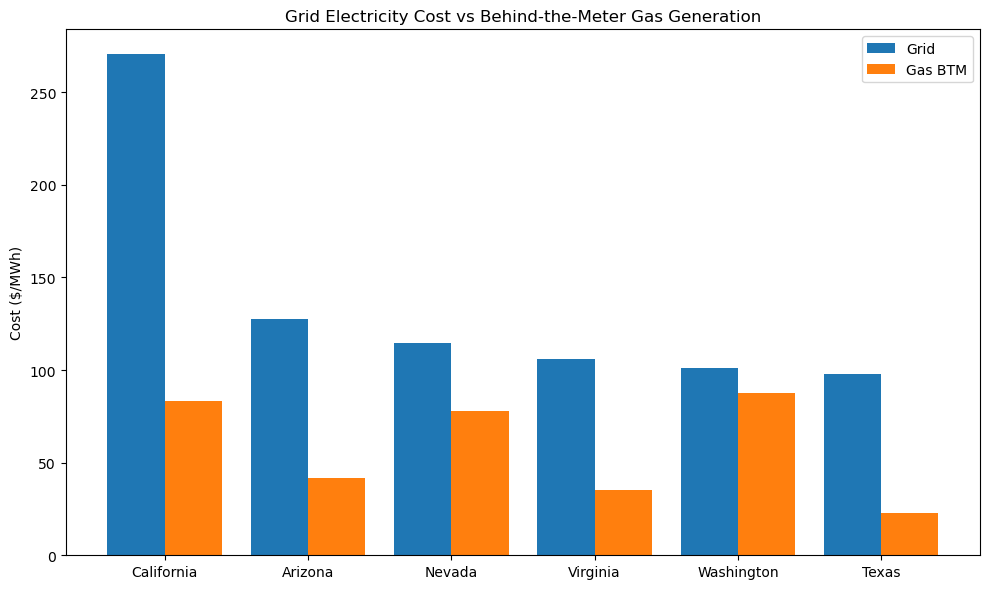

In [46]:
import matplotlib.pyplot as plt

plot_df = btm_cost_comparison[
    [
        "State",
        "grid_cost_usd_per_mwh",
        "gas_cost_usd_per_mwh"
    ]
]

plot_df = plot_df.sort_values(
    "grid_cost_usd_per_mwh",
    ascending=False
)

plt.figure(figsize=(10,6))

x = range(len(plot_df))

plt.bar(
    [i - 0.2 for i in x],
    plot_df["grid_cost_usd_per_mwh"],
    width=0.4,
    label="Grid"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_df["gas_cost_usd_per_mwh"],
    width=0.4,
    label="Gas BTM"
)

plt.xticks(
    x,
    plot_df["State"]
)

plt.ylabel("Cost ($/MWh)")
plt.title(
    "Grid Electricity Cost vs Behind-the-Meter Gas Generation"
)

plt.legend()
plt.tight_layout()
plt.show()

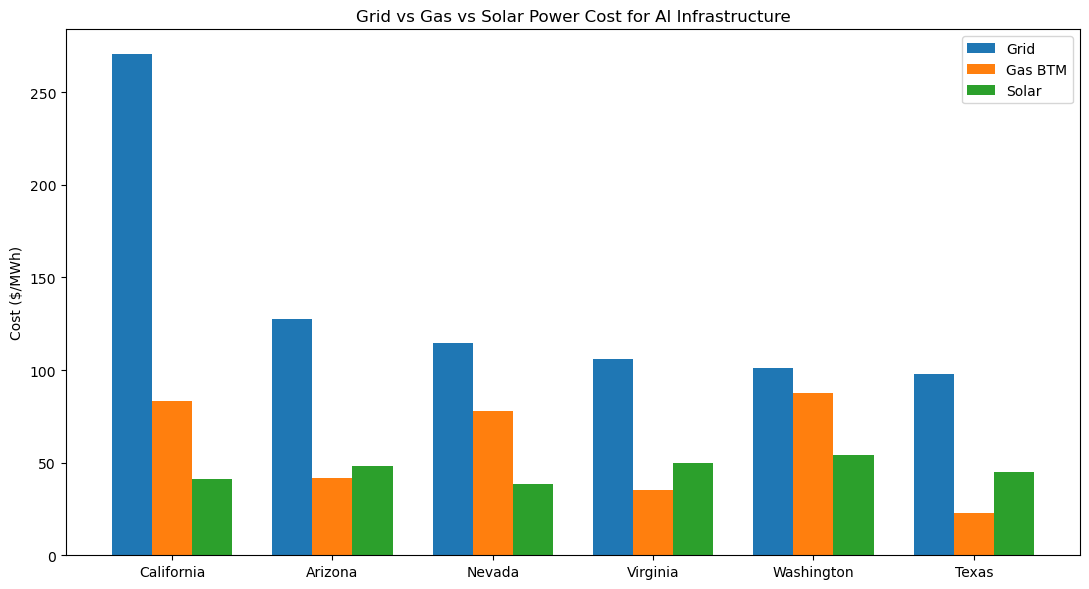

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = btm_cost_comparison[
    [
        "State",
        "grid_cost_usd_per_mwh",
        "gas_cost_usd_per_mwh",
        "solar_cost_usd_per_mwh"
    ]
].sort_values("grid_cost_usd_per_mwh", ascending=False)

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    plot_df["grid_cost_usd_per_mwh"],
    width,
    label="Grid"
)

plt.bar(
    x,
    plot_df["gas_cost_usd_per_mwh"],
    width,
    label="Gas BTM"
)

plt.bar(
    x + width,
    plot_df["solar_cost_usd_per_mwh"],
    width,
    label="Solar"
)

plt.xticks(x, plot_df["State"])
plt.ylabel("Cost ($/MWh)")
plt.title("Grid vs Gas vs Solar Power Cost for AI Infrastructure")
plt.legend()
plt.tight_layout()
plt.show()

## Scenario D: Hybrid Solar + Storage + Gas Backup

In [41]:
def calculate_hybrid_cost(row):

    solar_cost, _ = calculate_solar_cost(row)

    gas_cost, _ = calculate_gas_cost(row)

    battery_adder = 15

    hybrid_cost = (
        0.60 * solar_cost
        + 0.40 * gas_cost
        + battery_adder
    )

    annual_energy_mwh = (
        DATA_CENTER_LOAD_MW * 8760
    )

    annual_cost = (
        hybrid_cost
        * annual_energy_mwh
    )

    return hybrid_cost, annual_cost

In [48]:
comparison_cols = [
    "grid_cost_usd_per_mwh",
    "gas_cost_usd_per_mwh",
    "solar_cost_usd_per_mwh",
    "hybrid_cost_usd_per_mwh"
]

architecture_results = btm_cost_comparison.copy()

architecture_results["lowest_cost_usd_per_mwh"] = (
    architecture_results[comparison_cols]
    .min(axis=1)
)

architecture_results["best_architecture"] = (
    architecture_results[comparison_cols]
    .idxmin(axis=1)
)

architecture_results[
    [
        "State",
        "best_architecture",
        "lowest_cost_usd_per_mwh"
    ]
]

,State,best_architecture,lowest_cost_usd_per_mwh
0,Texas,gas_cost_usd_per_mwh,22.722936
1,Virginia,gas_cost_usd_per_mwh,35.075877
2,Arizona,gas_cost_usd_per_mwh,41.691114
3,California,solar_cost_usd_per_mwh,41.290197
4,Nevada,solar_cost_usd_per_mwh,38.619687
5,Washington,solar_cost_usd_per_mwh,54.283616


In [49]:
## Break-Even Analysis

In [50]:
grid_price_range = np.linspace(5, 30, 100)

break_even_df = pd.DataFrame({
    "grid_price_cents_per_kwh": grid_price_range,
    "grid_cost_usd_per_mwh": grid_price_range * 10
})

break_even_df.head()

,grid_price_cents_per_kwh,grid_cost_usd_per_mwh
0,5.000000,50.000000
1,5.252525,52.525253
2,5.505051,55.050505
3,5.757576,57.575758
4,6.010101,60.101010


In [51]:
import numpy as np

grid_price_range = np.linspace(5, 30, 100)

break_even_df = pd.DataFrame({
    "grid_price_cents_per_kwh": grid_price_range,
    "grid_cost_usd_per_mwh": grid_price_range * 10
})

break_even_df.head()

,grid_price_cents_per_kwh,grid_cost_usd_per_mwh
0,5.000000,50.000000
1,5.252525,52.525253
2,5.505051,55.050505
3,5.757576,57.575758
4,6.010101,60.101010


In [52]:
selected_state = "California"

state_row = btm_cost_comparison[
    btm_cost_comparison["State"] == selected_state
].iloc[0]

break_even_df["gas_cost_usd_per_mwh"] = state_row["gas_cost_usd_per_mwh"]
break_even_df["solar_cost_usd_per_mwh"] = state_row["solar_cost_usd_per_mwh"]
break_even_df["hybrid_cost_usd_per_mwh"] = state_row["hybrid_cost_usd_per_mwh"]

break_even_df.head()

,grid_price_cents_per_kwh,grid_cost_usd_per_mwh,gas_cost_usd_per_mwh,solar_cost_usd_per_mwh,hybrid_cost_usd_per_mwh
0,5.000000,50.000000,83.205096,41.290197,73.056157
1,5.252525,52.525253,83.205096,41.290197,73.056157
2,5.505051,55.050505,83.205096,41.290197,73.056157
3,5.757576,57.575758,83.205096,41.290197,73.056157
4,6.010101,60.101010,83.205096,41.290197,73.056157


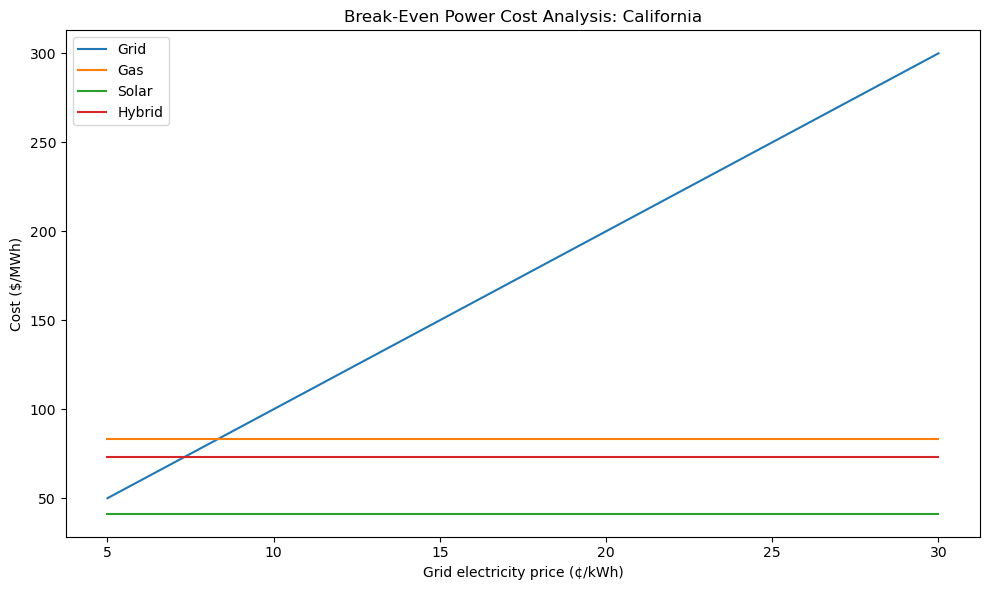

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    break_even_df["grid_price_cents_per_kwh"],
    break_even_df["grid_cost_usd_per_mwh"],
    label="Grid"
)

plt.plot(
    break_even_df["grid_price_cents_per_kwh"],
    break_even_df["gas_cost_usd_per_mwh"],
    label="Gas"
)

plt.plot(
    break_even_df["grid_price_cents_per_kwh"],
    break_even_df["solar_cost_usd_per_mwh"],
    label="Solar"
)

plt.plot(
    break_even_df["grid_price_cents_per_kwh"],
    break_even_df["hybrid_cost_usd_per_mwh"],
    label="Hybrid"
)

plt.xlabel("Grid electricity price (¢/kWh)")
plt.ylabel("Cost ($/MWh)")
plt.title(f"Break-Even Power Cost Analysis: {selected_state}")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
break_even_summary = btm_cost_comparison[
    [
        "State",
        "grid_cost_usd_per_mwh",
        "gas_cost_usd_per_mwh",
        "solar_cost_usd_per_mwh",
        "hybrid_cost_usd_per_mwh"
    ]
].copy()

break_even_summary["grid_price_needed_to_match_gas_cents_per_kwh"] = (
    break_even_summary["gas_cost_usd_per_mwh"] / 10
)

break_even_summary["grid_price_needed_to_match_solar_cents_per_kwh"] = (
    break_even_summary["solar_cost_usd_per_mwh"] / 10
)

break_even_summary["grid_price_needed_to_match_hybrid_cents_per_kwh"] = (
    break_even_summary["hybrid_cost_usd_per_mwh"] / 10
)

break_even_summary[
    [
        "State",
        "grid_price_needed_to_match_gas_cents_per_kwh",
        "grid_price_needed_to_match_solar_cents_per_kwh",
        "grid_price_needed_to_match_hybrid_cents_per_kwh"
    ]
]

,State,grid_price_needed_to_match_gas_cents_per_kwh,grid_price_needed_to_match_solar_cents_per_kwh,grid_price_needed_to_match_hybrid_cents_per_kwh
0,Texas,2.272294,4.513115,5.116786
1,Virginia,3.507588,5.008101,5.907896
2,Arizona,4.169111,4.821464,6.060523
3,California,8.320510,4.129020,7.305616
4,Nevada,7.787241,3.861969,6.932077
5,Washington,8.759275,5.428362,8.260727


In [55]:
break_even_summary

,State,grid_cost_usd_per_mwh,gas_cost_usd_per_mwh,solar_cost_usd_per_mwh,hybrid_cost_usd_per_mwh,grid_price_needed_to_match_gas_cents_per_kwh,grid_price_needed_to_match_solar_cents_per_kwh,grid_price_needed_to_match_hybrid_cents_per_kwh
0,Texas,97.9,22.722936,45.131146,51.167862,2.272294,4.513115,5.116786
1,Virginia,106.2,35.075877,50.081013,59.078959,3.507588,5.008101,5.907896
2,Arizona,127.4,41.691114,48.214640,60.605230,4.169111,4.821464,6.060523
3,California,270.4,83.205096,41.290197,73.056157,8.320510,4.129020,7.305616
4,Nevada,114.7,77.872406,38.619687,69.320775,7.787241,3.861969,6.932077
5,Washington,101.3,87.592753,54.283616,82.607271,8.759275,5.428362,8.260727


## Key Finding

Under baseline assumptions, the lowest-cost power architecture differs by state.

Natural gas is lowest-cost in Texas, Virginia, and Arizona.

Solar is lowest-cost in California, Nevada, and Washington.

Hybrid solar + storage + gas does not win on pure cost in the baseline model, but it remains strategically important because it adds reliability and dispatchability that solar-only systems lack.

The main insight is not that one power source dominates everywhere. The main insight is that AI infrastructure power strategy is geographically dependent.